# Learning about derivative first using two and three variable function


In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Defining a function randomly
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

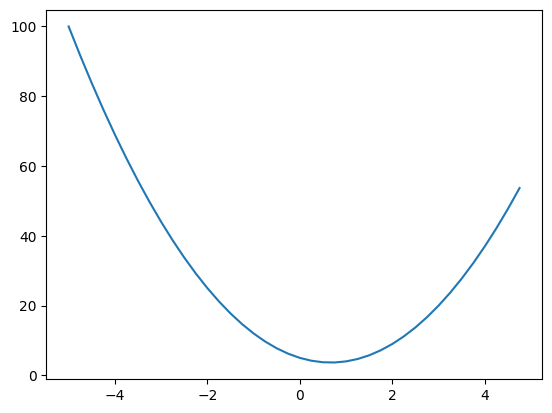

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
# The value of derivative is 0.0 as the function has zero slope at x = 2/3
h = 0.00000001
x = 2/3
(f(x+h)-f(x))/h

0.0

In [6]:
# lets get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print (d)

4.0


In [7]:
#calculating derivative (the effect of small change in the value of given three variables on the value of d)
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

# for a
d1 = a*b + c
a += h
d2 = a*b + c

print('For "a"')
print('d1', d1)
print('d2', d2)
#print slope
print((d2-d1)/h)

# for b
d1 = a*b + c
b += h
d2 = a*b + c

print('For "b"')
print('d1', d1)
print('d2', d2)
#print slope
print((d2-d1)/h)

# for c
d1 = a*b + c
c += h
d2 = a*b + c

print('For "c"')
print('d1', d1)
print('d2', d2)
#print slope
print((d2-d1)/h)

For "a"
d1 4.0
d2 3.999699999999999
-3.000000000010772
For "b"
d1 3.999699999999999
d2 3.99990001
2.0001000000124947
For "c"
d1 3.99990001
d2 4.00000001
0.9999999999976694


# Implementing the value object from micrograd 

In [8]:
# Value Object
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    # Displaying Object
    def __repr__(self):
        return f"Value(data={self.data})"

    # Adding two Value objects
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    # Multiplying two Value objects
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self,other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    # Taking power of a Value object to a integer or floating point value
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self,), f'**{other}')
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        
        out._backward = _backward
        return out

    # Do reverse multiplication if normal multiplication doesn't work
    def __rmul__(self, other):
        return self * other

    # Dividing a Value object by another object
    def __truediv__(self, other):
        return self * other**-1

    # Negation
    def __neg__(self):
        return self * -1


    # Subtraction
    def __sub__(self, other):
        return self + (-other)

    # For implementing tanh (Hyperbolic Activation Function) from scratch on Value object
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), "tanh")
        
        def _backward():
            self.grad = (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def backward():
            self.grad += out.data * out.grad
        out._backward = backward

        return out

    # For implementing backard as a method of class to compute gradient descend
    def backward(self):
        self.grad = 1.0
        topo = []
        visited = set()
        
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        
        build_topo(self)
        topo
        for node in reversed(topo):
            node._backward()
    

# For Visualization

In [9]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op, shape='circle')
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

# Implementing Backpropagationg using a simple neuron 

### PLoting the tanh activation function from pyplot


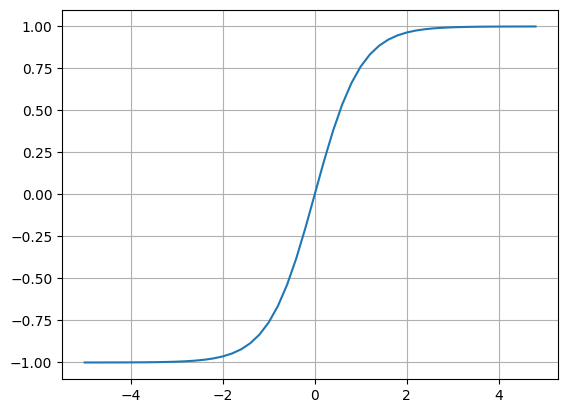

In [10]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid()

### Simple Neuron

In [11]:
# Inputs x1 and x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# Weights w1 and w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# Bias
b = Value(6.8813735870195432, label='b')

# calculating product
x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'

# adding all the inputs multiplied by their weights
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1*w1 + x2w2'

# computing expression
n = x1w1x2w2+b; n.label='n'

# calculating output
o = n.tanh(); o.label='o'
o.backward()

### Visual representation of Neuron

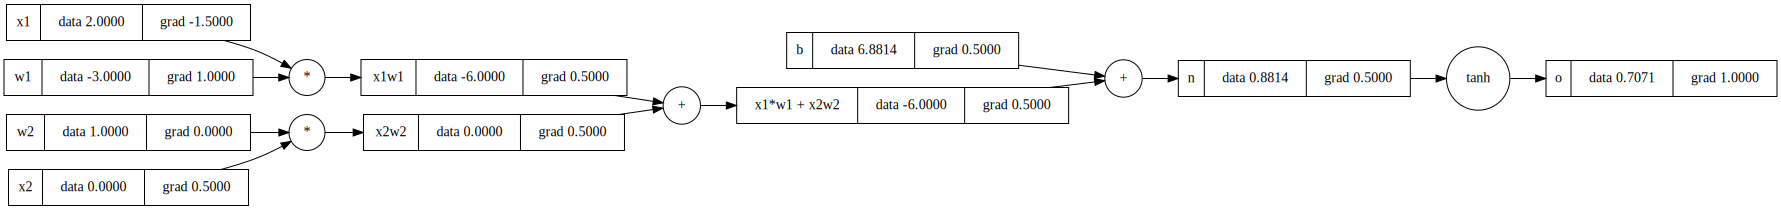

In [12]:
draw_dot(o)

### Implementing tanh from scratch

In [13]:
# Inputs x1 and x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# Weights w1 and w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# Bias
b = Value(6.8813735870195432, label='b')

# calculating product
x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'

# adding all the inputs multiplied by their weights
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1*w1 + x2w2'

# computing expression
n = x1w1x2w2+b; n.label='n'

# calculating output
e = (2*n).exp()
o = (e-1)/(e+1)
o.backward()

### Redrawing graph as tanh is implemented from scratch

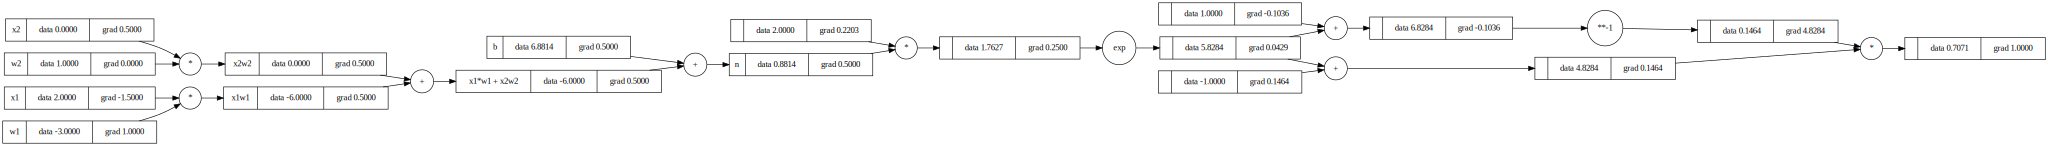

In [14]:
draw_dot(o)

## Arranging nodes in Topological order

In [15]:
topo = []
visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)
topo

[Value(data=1),
 Value(data=2),
 Value(data=6.881373587019543),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=1.7627471740390863),
 Value(data=5.828427124746192),
 Value(data=6.828427124746192),
 Value(data=0.1464466094067262),
 Value(data=-1),
 Value(data=4.828427124746192),
 Value(data=0.7071067811865477)]

### Finding Bug

#### Case 1

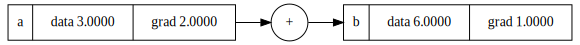

In [16]:
a = Value(3.0, label='a')
b = a + a; b.label='b'
b.backward()
draw_dot(b)
# The value of the gradient of a is incorrect

#### Case 2

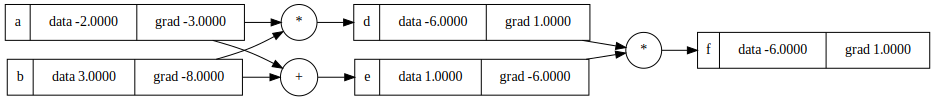

In [17]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label='d'
e = a + b; e.label='e'
f = d * e; f.label='f'

f.backward()

draw_dot(f)

In [18]:
# Making sure all operations work properly
a = Value(2.0)
b = Value(4.0)
a - b

Value(data=-2.0)

# Implementing the above using Pytorch

In [19]:
import torch

# Initialize tensors with double precision
x1 = torch.tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.tensor([6.8813735870195432]).double()  ; b.requires_grad = True

# Forward pass
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

# Output result and perform backpropagation
print(o.data.item())
o.backward()

# Print gradients
print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


### Value of Tensor o

In [20]:
# o.item() and o.data.item() are the same
# Printing o
# o

# Printing the value of o
# o.item()

# Datatype of o tensor is float32 by default we changed it to double for precision explicitly
# o.data.dtype

# Implementing Neural Net from scratch

### Defining class Neuron

In [27]:
class Neuron:
    
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # w*x+b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

# instance
x = [2.0, 3.0]
n = Neuron(2)
n(x)
        

Value(data=0.962167521992058)

### Definig class Layer

In [32]:
# here nin defines the number of inputs to each neuron and nout determines the number of neurons in the layer
class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

# instance
x = [2.0, 3.0]
l = Layer(2, 3)
l(x)

[Value(data=-0.983524726345251),
 Value(data=0.9988964022214104),
 Value(data=0.9773054082946914)]

### Multi Layer Perceptron (MLP)

### Defining class MLP

In [33]:
# here nin defines number of input features and nouts is a list describing neurons in each layer
class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


In [34]:
# Example
# defining inputs
x = [2.0, 3.0, -1.0]

# defining a Neural Net of 4 layers(1 input, 2 hidden, 1 output) 
# So layers are:

# Layer 1: 3 → 4 neurons
# Layer 2: 4 → 4 neurons
# Layer 3: 4 → 1 neuron

l = MLP(3, [4, 4, 1])
l(x)

Value(data=0.805326076450141)

## Drawing the above Neural Net

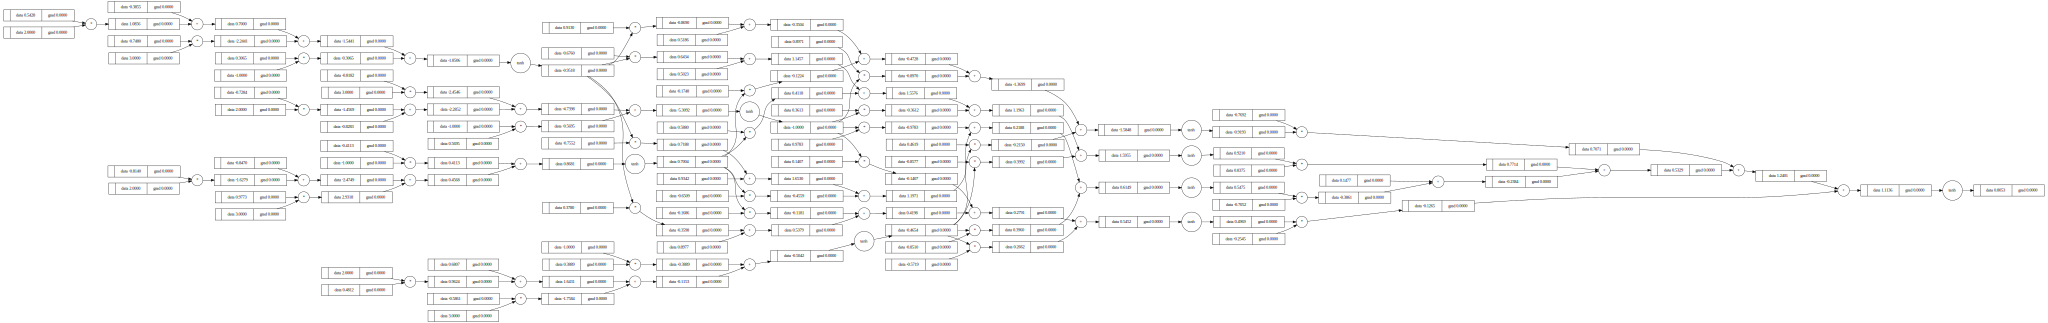

In [35]:
draw_dot(l(x))